# Week 3 Day 4 — Daily Svensson Loop

Runs `fit_svensson_daily` over the full history and explores the resulting
time series of parameters.

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from termstructure.curves.svensson import fit_svensson_daily, svensson_zero_rate

## 1. Run the full historical loop

This takes a few minutes for the full history (1961–present).
The result is saved to `data/processed/svensson_params.parquet`
so you only need to run it once.

In [2]:
params_df = fit_svensson_daily('1961-06-14', '2024-12-31')
params_df.head()

Fitting 15852 dates from 1961-06-14 to 2024-12-31...
      0/15852 ( 0%)  1961-06-14
    250/15852 (2%)  1962-06-14  ETA 0.2 min
    500/15852 (3%)  1963-06-17  ETA 0.2 min
    750/15852 (5%)  1964-06-17  ETA 0.2 min
   1000/15852 (6%)  1965-06-18  ETA 0.2 min
   1250/15852 (8%)  1966-06-17  ETA 0.2 min
   1500/15852 (9%)  1967-06-20  ETA 0.2 min
   1750/15852 (11%)  1968-06-20  ETA 0.2 min
   2000/15852 (13%)  1969-06-20  ETA 0.2 min
   2250/15852 (14%)  1970-06-23  ETA 0.1 min
   2500/15852 (16%)  1971-06-24  ETA 0.1 min
   2750/15852 (17%)  1972-06-22  ETA 0.2 min
   3000/15852 (19%)  1973-06-25  ETA 0.3 min
   3250/15852 (21%)  1974-06-27  ETA 0.4 min
   3500/15852 (22%)  1975-06-30  ETA 0.4 min
   3750/15852 (24%)  1976-06-30  ETA 0.5 min
   4000/15852 (25%)  1977-06-29  ETA 0.5 min
   4250/15852 (27%)  1978-07-06  ETA 0.5 min
   4500/15852 (28%)  1979-07-09  ETA 0.5 min
   4750/15852 (30%)  1980-07-09  ETA 0.6 min
   5000/15852 (32%)  1981-07-10  ETA 0.6 min
   5250/15852 (33%)  

,date,beta0,beta1,beta2,beta3,lambda1,lambda2,rmse_bps,n_bonds
0,1971-08-16,0.063594,-0.021384,0.003669,0.000003,0.364357,4.241623,0.007402,10
1,1971-08-17,0.062173,-0.019113,-0.000314,-0.000007,0.471733,4.369760,0.005467,10
2,1971-08-18,0.065036,-0.016421,-0.000810,0.004921,1.422191,7.546280,0.041860,10
3,1971-08-19,0.065222,-0.017593,-0.001257,0.004537,1.520317,8.167237,0.026507,10
4,1971-08-20,0.064827,-0.017860,0.002715,0.001813,1.324590,8.297926,0.007740,10


## 2. Quick quality check

Median RMSE should be well under 1 bp (we're fitting to the Fed's already-smooth zero yields).
Any day above 5 bp is suspicious — probably a data gap or optimizer stumble.

In [3]:
print(f'Dates fitted:      {len(params_df):,}')
print(f'RMSE median:       {params_df.rmse_bps.median():.3f} bp')
print(f'RMSE 95th pctile:  {params_df.rmse_bps.quantile(0.95):.3f} bp')
print(f'RMSE max:          {params_df.rmse_bps.max():.3f} bp')
print(f'Days > 5 bp:       {(params_df.rmse_bps > 5).sum()}')

Dates fitted:      13,315
RMSE median:       0.377 bp
RMSE 95th pctile:  13.083 bp
RMSE max:          38.152 bp
Days > 5 bp:       2219


## 3. Parameter time series

Each parameter has an economic meaning:
- **β0**: long-run rate — tracks secular decline from ~15% in 1982 to ~4% post-2022
- **β1**: slope loading — negative means upward-sloping curve (normal)
- **β2, β3**: hump shapes — harder to interpret alone, but together they shape the middle of the curve

Note: individual parameter values can be noisy because Svensson is ill-conditioned
(many parameter sets give equally good fits). The *curve* is stable even when
parameters vary — what matters for Week 5 is the fitted zero rate, not the params.

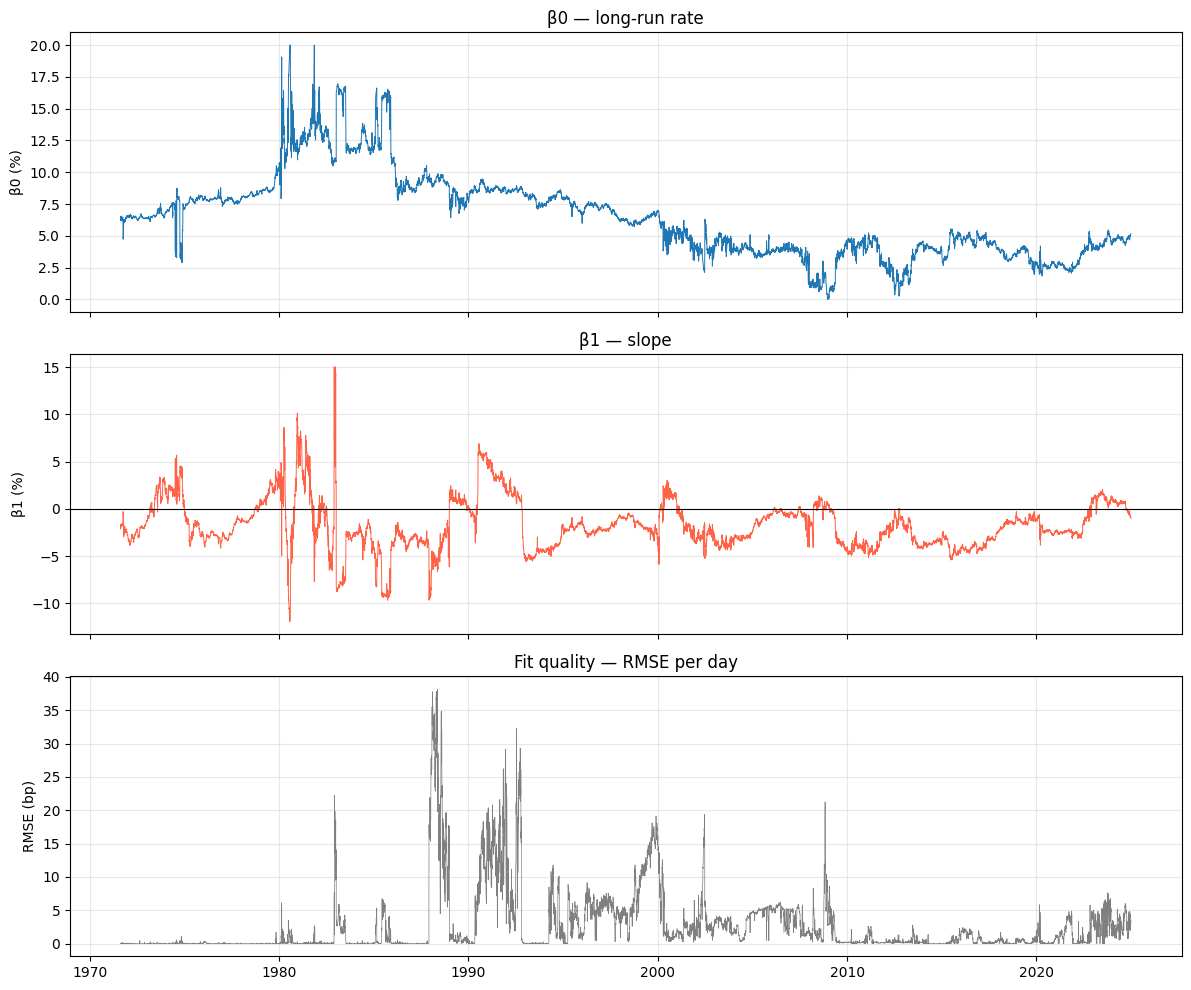

In [4]:
params_df = params_df.set_index('date')

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

axes[0].plot(params_df.index, params_df.beta0 * 100, lw=0.7)
axes[0].set_ylabel('β0 (%)')
axes[0].set_title('β0 — long-run rate')
axes[0].grid(True, alpha=0.3)

axes[1].plot(params_df.index, params_df.beta1 * 100, lw=0.7, color='tomato')
axes[1].set_ylabel('β1 (%)')
axes[1].set_title('β1 — slope')
axes[1].axhline(0, color='black', lw=0.8)
axes[1].grid(True, alpha=0.3)

axes[2].plot(params_df.index, params_df.rmse_bps, lw=0.5, color='gray')
axes[2].set_ylabel('RMSE (bp)')
axes[2].set_title('Fit quality — RMSE per day')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('data/week3_day4_params.png', dpi=150)
plt.show()

## 4. Compare our β0 to the Fed's published β0

The Fed's parameters are in the same parquet (columns beta0–beta3, tau1, tau2).
As noted in notebook 11, individual parameter values often differ because Svensson
is ill-conditioned. The comparison that *matters* is the fitted curve, not the params.
We'll do the full curve comparison in Day 5.

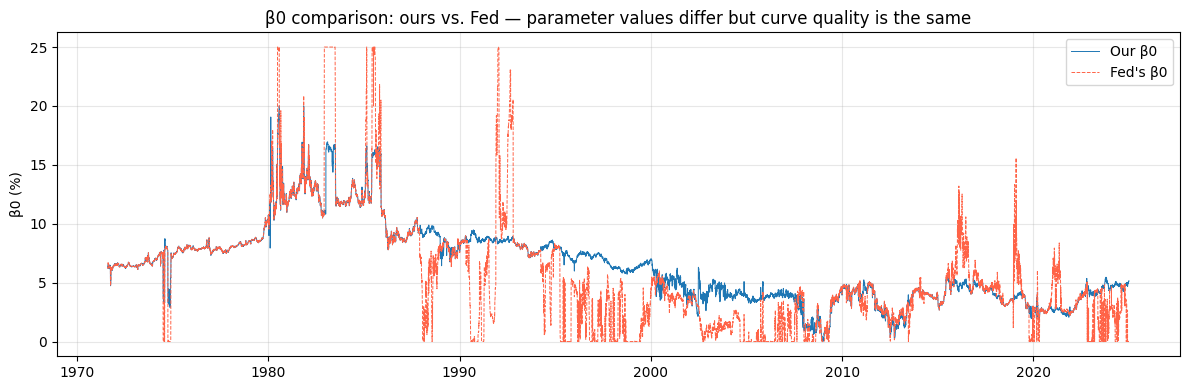

β0 correlation: 0.7946475267137225


In [5]:
fed = pd.read_parquet('../data/processed/treasury_bonds.parquet')
fed['date'] = pd.to_datetime(fed['date'])
fed = fed.set_index('date').sort_index()

common = params_df.index.intersection(fed.index)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(common, params_df.loc[common, 'beta0'] * 100, label='Our β0', lw=0.7)
ax.plot(common, fed.loc[common, 'beta0'], label="Fed's β0", lw=0.7, linestyle='--', color='tomato')
ax.set_title('β0 comparison: ours vs. Fed — parameter values differ but curve quality is the same')
ax.set_ylabel('β0 (%)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('β0 correlation:', params_df.loc[common, 'beta0'].corr(fed.loc[common, 'beta0']))